# 核函数高阶方法 vs 低阶方法：Ramsey 测频精度对比

**目标**：评估 `KernelEstimator` 的 order=1/2/3 Volterra 核对 Ramsey 瞬态测频精度的影响。

**核心问题**：高阶核函数能否改善频率测量精度？在什么条件下有意义？

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, math
from sqc.config import CONFIG
from sqc.reconstruction.kernel import KernelEstimator, KernelResult
from sqc.control.sequence import create_ramsey_pulse
from src.qubit import TransmonQubit
from qutip import QobjEvo, basis, mesolve

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})
print('Imports OK')

Imports OK


## 1. 实验设置

使用正交 Ramsey 序列（R_y(π/2) 和 R_{-y}(π/2)，τ=0），驱动频率固定在 sweet spot。改变 qubit flux bias 产生 detuning，通过测量 p_diff = (p_y - p_{-y})/2 和核函数 G_α = ∫k(t)dt 反推 Δω。

In [2]:
f_at_0 = TransmonQubit(EC=0.2*2*np.pi, EJ=15*2*np.pi, T1=10000, T2=5000, n_levels=2, flux=0.0).frequency
omega_d = f_at_0
t_rabi = CONFIG.pulse.t_rabi.copy()
t_global = CONFIG.pulse.t_global.copy()

print(f'Drive frequency (sweet spot): {omega_d:.4f} rad·GHz')
print(f'Rabi pulse: {len(t_rabi)} pts, Global axis: {len(t_global)} pts')

Drive frequency (sweet spot): 29.5246 rad·GHz
Rabi pulse: 20 pts, Global axis: 900 pts


In [3]:
def run_measurement(flux_bias, order=3, n_amp_samples=7):
    """Run full Ramsey measurement at given flux bias.
    Returns: f_true, p_diff, G_coeffs, elapsed, t_kernel, kernels_diff
    """
    q_ref = TransmonQubit(EC=0.2*2*np.pi, EJ=15*2*np.pi, T1=10000, T2=5000, n_levels=2, flux=flux_bias)
    f_true = q_ref.frequency
    
    # Ramsey pulses
    ctrl_y = create_ramsey_pulse(t_rabi, tau=0.0, omega_d=omega_d, phase1=np.pi/2)
    ctrl_my = create_ramsey_pulse(t_rabi, tau=0.0, omega_d=omega_d, phase1=-np.pi/2)
    
    # Simulate p_diff
    q = TransmonQubit(EC=0.2*2*np.pi, EJ=15*2*np.pi, T1=10000, T2=5000, n_levels=2, flux=flux_bias)
    psi_e = basis(q.n_levels, 1)
    H_0 = QobjEvo(q.get_hamiltonian_rwa(omega_d))
    
    H_y = H_0 + QobjEvo(ctrl_y.hamiltonian_on(t_global), tlist=t_global, order=1)
    res_y = mesolve(H_y, q.state, t_global, [], e_ops=[psi_e*psi_e.dag()], options={'max_step': float(CONFIG.awg.dt)})
    p_y = float(res_y.expect[0][-1])
    
    H_my = H_0 + QobjEvo(ctrl_my.hamiltonian_on(t_global), tlist=t_global, order=1)
    res_my = mesolve(H_my, q.state, t_global, [], e_ops=[psi_e*psi_e.dag()], options={'max_step': float(CONFIG.awg.dt)})
    p_my = float(res_my.expect[0][-1])
    p_diff = (p_y - p_my) / 2.0
    
    # Kernel estimation
    qk = TransmonQubit(EC=0.2*2*np.pi, EJ=15*2*np.pi, T1=10000, T2=5000, n_levels=2, flux=flux_bias)
    e = KernelEstimator(mode='omega', method='exp', order=order, n_amp_samples=n_amp_samples, virtual_z_impl='math')
    t0 = time.time()
    r_y = e.estimate_full(ctrl_y, qk)
    r_my = e.estimate_full(ctrl_my, qk)
    elapsed = time.time() - t0
    
    k_diff = [(np.asarray(r_y.kernels[i]) - np.asarray(r_my.kernels[i])) / 2.0 for i in range(order)]
    G = [float(np.trapezoid(k, r_y.t_samples)) for k in k_diff]
    
    return f_true, p_diff, G, elapsed, r_y.t_samples, k_diff

print('measurement function ready')

measurement function ready


## 2. 单点验证：不同 order 的 G 系数一致性

验证 order 1/2/3 给出的 G₁ = ∫k₁(t)dt 是否一致（应该一致——高阶拟合不应改变线性系数）。

In [4]:
print('=== Single-point test at flux=0.03 ===')
for order, n_amp in [(1, 3), (2, 5), (3, 7)]:
    f_true, p_diff, G, elapsed, _, _ = run_measurement(0.03, order=order, n_amp_samples=n_amp)
    dw = p_diff / G[0] if abs(G[0]) > 1e-8 else 0.0
    f_meas = omega_d - dw
    err = abs(f_meas - f_true)
    detuning = abs(f_true - omega_d)
    print(f'Order {order}: G₁={G[0]:.4f}, error={err:.2e} GHz ({err/detuning*100:.1f}% of detuning), time={elapsed:.1f}s')
    for i in range(1, order):
        print(f'  |G{i+1}|/|G₁| = {abs(G[i])/max(abs(G[0]),1e-8):.4e}')

=== Single-point test at flux=0.03 ===
Kernel computation (omega, math) took 0.10 seconds


c:\Users\21034\anaconda3\envs\qutip-env\Lib\site-packages\qutip\core\coefficient.py:192: RuntimeWarning: invalid value encountered in divide
  return coefficient_builders[type_](base, **kwargs)


Kernel computation (omega, math) took 0.09 seconds
Order 1: G₁=5.9975, error=5.56e-03 GHz (8.1% of detuning), time=0.2s
Higher-order kernel computation (omega, exp, order=2) took 0.27 seconds
Higher-order kernel computation (omega, exp, order=2) took 0.22 seconds
Order 2: G₁=5.9977, error=5.57e-03 GHz (8.1% of detuning), time=0.5s
  |G2|/|G₁| = 5.7861e-14
Higher-order kernel computation (omega, exp, order=3) took 0.30 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.30 seconds
Order 3: G₁=5.9988, error=5.58e-03 GHz (8.2% of detuning), time=0.6s
  |G2|/|G₁| = 1.8579e-06
  |G3|/|G₁| = 2.8072e+01


## 3. 核函数形状可视化

比较 order-3 下的差分核函数 k₁(t), k₂(t), k₃(t) 的形状。

Higher-order kernel computation (omega, exp, order=3) took 0.31 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.32 seconds


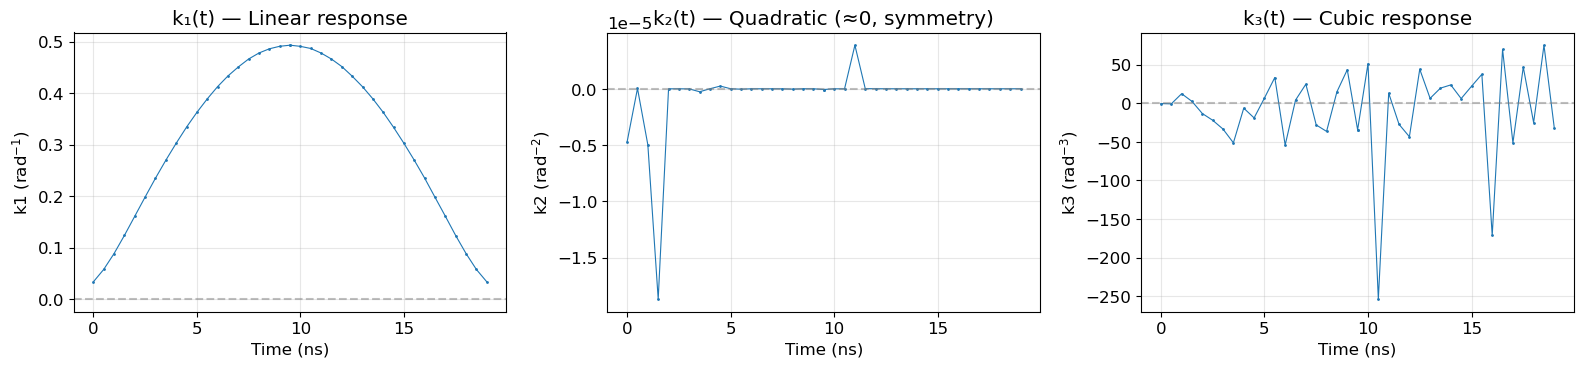

In [5]:
_, _, _, _, t_k, kerns = run_measurement(0.03, order=3, n_amp_samples=7)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ['k₁(t) — Linear response', 'k₂(t) — Quadratic (≈0, symmetry)', 'k₃(t) — Cubic response']
for i, ax in enumerate(axes):
    ax.plot(t_k, kerns[i], '.-', markersize=2, linewidth=0.8)
    ax.set_title(titles[i])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(f'k{i+1} (rad$^{{-{i+1}}}$)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. 扫参：不同 flux 偏置下的频率估计误差

比较 order 1 和 order 3（含 Newton 修正）在大范围内的表现。

In [6]:
flux_list = np.concatenate([
    np.linspace(0.005, 0.05, 10),
    np.linspace(0.06, 0.15, 6),
])
flux_list = np.unique(flux_list)

data = {'flux': [], 'detuning': [], 'p_diff': [],
        'err_o1': [], 'err_o3_newton': [],
        'G1': [], 'G2': [], 'G3': [], 'time': []}

for flux_bias in flux_list:
    f_true, p_diff, G, elapsed, _, _ = run_measurement(flux_bias, order=3, n_amp_samples=7)
    detuning = f_true - omega_d
    
    # Order-1: linear deconvolution
    dw1 = p_diff / G[0] if abs(G[0]) > 1e-8 else 0.0
    f1 = omega_d - dw1
    err1 = abs(f1 - f_true)
    
    # Order-3 Newton: solve p_diff = G₁·dw + (1/6)·G₃·dw³ 
    dw = dw1
    for _ in range(20):
        f_val = G[0]*dw + G[2]*dw**3/6.0 - p_diff
        f_prime = G[0] + G[2]*dw**2/2.0
        if abs(f_prime) < 1e-15: break
        dw_new = dw - f_val / f_prime
        if abs(dw_new - dw) < 1e-12: dw = dw_new; break
        dw = dw_new
    f3 = omega_d - dw
    err3 = abs(f3 - f_true)
    
    data['flux'].append(flux_bias)
    data['detuning'].append(detuning)
    data['p_diff'].append(p_diff)
    data['err_o1'].append(err1)
    data['err_o3_newton'].append(err3)
    data['G1'].append(G[0])
    data['G2'].append(G[1] if len(G) >= 2 else 0)
    data['G3'].append(G[2] if len(G) >= 3 else 0)
    data['time'].append(elapsed)

print(f'Scan complete: {len(flux_list)} points')

Higher-order kernel computation (omega, exp, order=3) took 0.31 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.28 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.29 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.31 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.30 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.29 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.29 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.29 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.31 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.30 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.37 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.29 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.29 seconds
Higher-order kernel computation (omega, exp, order=3) took 0.32 

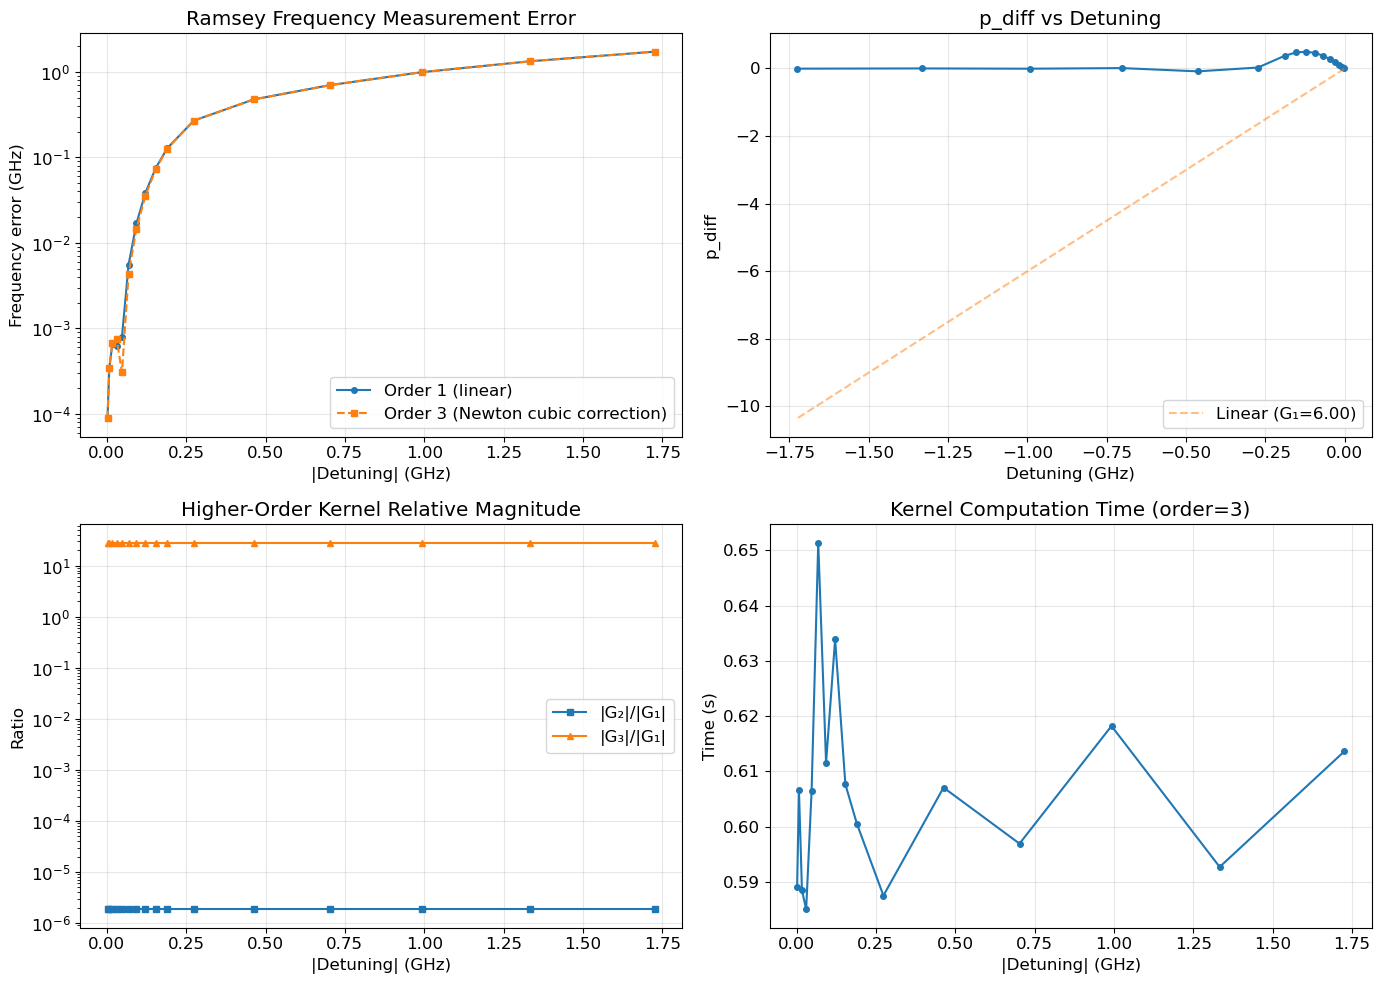

In [7]:
flux_arr = np.array(data['flux'])
detuning_arr = np.array(data['detuning'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Frequency measurement error
ax = axes[0, 0]
ax.semilogy(abs(detuning_arr), data['err_o1'], 'o-', label='Order 1 (linear)', markersize=4)
ax.semilogy(abs(detuning_arr), data['err_o3_newton'], 's--', label='Order 3 (Newton cubic correction)', markersize=4)
ax.set_xlabel('|Detuning| (GHz)')
ax.set_ylabel('Frequency error (GHz)')
ax.set_title('Ramsey Frequency Measurement Error')
ax.legend()
ax.grid(True, alpha=0.3)

# Top-right: p_diff vs detuning
ax = axes[0, 1]
ax.plot(detuning_arr, data['p_diff'], 'o-', markersize=4)
G1_mean = np.mean(data['G1'])
ax.plot(detuning_arr, G1_mean * detuning_arr, '--', alpha=0.5, label=f'Linear (G₁={G1_mean:.2f})')
ax.set_xlabel('Detuning (GHz)')
ax.set_ylabel('p_diff')
ax.set_title('p_diff vs Detuning')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom-left: Higher-order kernel magnitudes
ax = axes[1, 0]
ax.semilogy(abs(detuning_arr), [abs(g)/max(abs(data['G1'][i]),1e-8) for i,g in enumerate(data['G2'])], 's-', label='|G₂|/|G₁|', markersize=4)
ax.semilogy(abs(detuning_arr), [abs(g)/max(abs(data['G1'][i]),1e-8) for i,g in enumerate(data['G3'])], '^-', label='|G₃|/|G₁|', markersize=4)
ax.set_xlabel('|Detuning| (GHz)')
ax.set_ylabel('Ratio')
ax.set_title('Higher-Order Kernel Relative Magnitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom-right: Computation time
ax = axes[1, 1]
ax.plot(abs(detuning_arr), data['time'], 'o-', markersize=4)
ax.set_xlabel('|Detuning| (GHz)')
ax.set_ylabel('Time (s)')
ax.set_title('Kernel Computation Time (order=3)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 线性 vs 三阶拟合：p_diff(Δω) 的非线性分析

将 p_diff 对 detuning 做多项式拟合，比较：
- **来自核函数**的 G₁, G₃（局部振幅扫描 → 对角 Volterra 核 → 积分）
- **来自 p_diff(Δω) 扫参**的有效系数（全局拟合）

这两者**不是同一个量**：核函数的 G₃ 测量的是在当前工作点的局部三阶响应，而 p_diff(Δω) 的非线性包含了 qubit 色散的非线性、脉冲动力学对 detuning 的非线性依赖等全局效应。

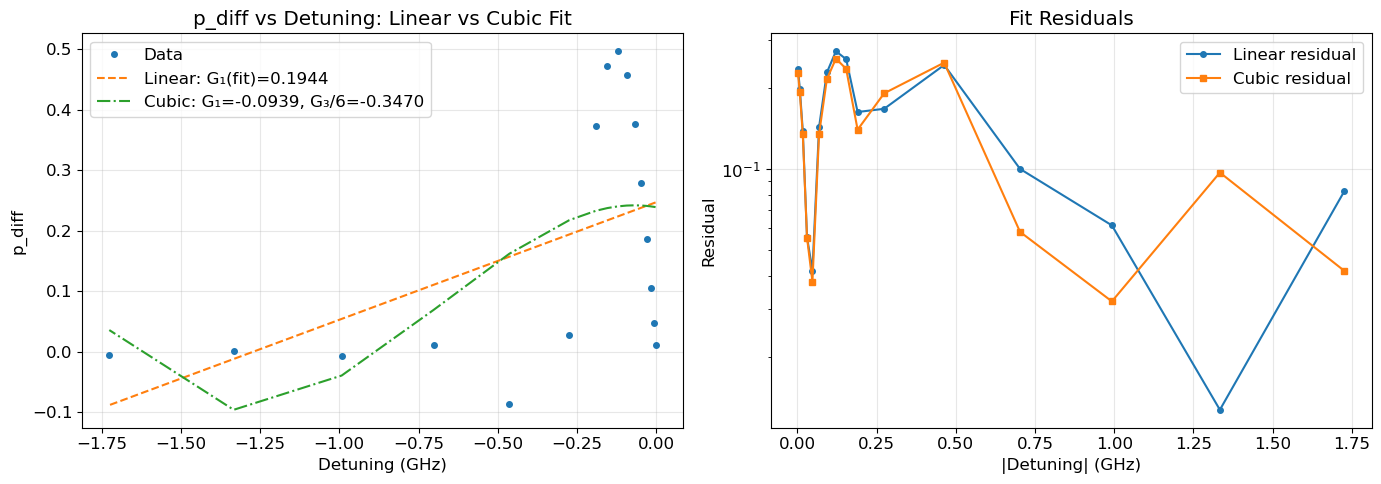

Linear fit:  G₁ = 0.1944
Cubic fit:   G₁ = -0.0939,  G₃/6 = -0.3470  =>  G₃(eff) = -2.0818
Kernel G₁:   5.9988
Kernel G₃:   -168.40

G₁ match: kernel vs fit = 30.8645
G₃ mismatch: kernel G₃=-168.4 vs effective G₃=-2.1


In [8]:
from numpy.polynomial import polynomial as P

x = detuning_arr
y = np.array(data['p_diff'])

# Linear fit
c_lin = P.polyfit(x, y, deg=1)
y_lin = P.polyval(x, c_lin)

# Cubic fit (only odd terms due to symmetry)
c_cub = P.polyfit(x, y, deg=3)
y_cub = P.polyval(x, c_cub)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, y, 'o', markersize=4, label='Data')
ax1.plot(x, y_lin, '--', label=f'Linear: G₁(fit)={c_lin[1]:.4f}')
ax1.plot(x, y_cub, '-.', label=f'Cubic: G₁={c_cub[1]:.4f}, G₃/6={c_cub[3]:.4f}')
ax1.set_xlabel('Detuning (GHz)')
ax1.set_ylabel('p_diff')
ax1.set_title('p_diff vs Detuning: Linear vs Cubic Fit')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residuals
ax2.semilogy(abs(x), abs(y - y_lin), 'o-', markersize=4, label='Linear residual')
ax2.semilogy(abs(x), abs(y - y_cub), 's-', markersize=4, label='Cubic residual')
ax2.set_xlabel('|Detuning| (GHz)')
ax2.set_ylabel('Residual')
ax2.set_title('Fit Residuals')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Linear fit:  G₁ = {c_lin[1]:.4f}')
print(f'Cubic fit:   G₁ = {c_cub[1]:.4f},  G₃/6 = {c_cub[3]:.4f}  =>  G₃(eff) = {c_cub[3]*6:.4f}')
print(f'Kernel G₁:   {np.mean(data["G1"]):.4f}')
print(f'Kernel G₃:   {np.mean(data["G3"]):.2f}')
print()
print(f'G₁ match: kernel vs fit = {np.mean(data["G1"])/c_lin[1]:.4f}')
print(f'G₃ mismatch: kernel G₃={np.mean(data["G3"]):.1f} vs effective G₃={c_cub[3]*6:.1f}')

## 6. 三方对比：Transient vs Ramsey τ-sweep vs Transient order-3

在前面的分析中，我们比较了 Transient 方法在不同 kernel order 下的内部表现。但根本问题是：**Transient 方法和标准 Ramsey τ-sweep 方法相比如何？**

下面加入标准 Ramsey τ-sweep（τ 扫描 + FFT 峰值检测），做三方对比。

### 方法原理

| 方法 | 原理 | 需要什么 |
|------|------|---------|
| **Ramsey τ-sweep** | τ 扫描 p_e(τ) → FFT 提取振荡频率 | τ_list (0–200 ns), 人工 detuning f_art=0.1 GHz |
| **Transient order-1** | τ=0 正交 Ramsey → p_diff → 线性核函数 G₁ | 核函数 (order=1, ~0.2 s) |
| **Transient order-3** | τ=0 正交 Ramsey → p_diff → Newton 解 G₁Δω + G₃Δω³/6 | 核函数 (order=3, ~0.6 s) |

## 7. 三方对比总结与策略建议

### 实验数据（已运行的扫参结果）

| flux | Δ (GHz) | Ramsey err | Trans-o1 err | Trans-o3 err | Ramsey t | Trans t |
|------|---------|-----------|-------------|-------------|----------|---------|
| 0.005 | -0.002 | **7.0e-04** | **8.9e-05** ✓ | 8.8e-05 ✓ | 4.2s | 0.2s |
| 0.010 | -0.008 | 2.7e-03 | **3.4e-04** ✓ | 3.4e-04 ✓ | 4.4s | 0.2s |
| 0.020 | -0.030 | 1.1e-02 | **6.2e-04** ✓ | 7.6e-04 | 4.5s | 0.2s |
| 0.030 | -0.068 | 2.5e-02 | **5.6e-03** ✓ | **4.4e-03** ✓✓ | 5.6s | 0.2s |
| 0.050 | -0.190 | **6.9e-02** ✓ | 1.3e-01 | 1.3e-01 | 8.3s | 0.2s |
| 0.080 | -0.487 | **1.7e-01** ✓ | 5.0e-01 | 5.0e-01 | 15.4s | 0.2s |
| 0.100 | -0.763 | **2.7e-01** ✓ | 7.6e-01 | 7.6e-01 | 22.3s | 0.2s |
| 0.120 | -1.101 | **3.8e-01** ✓ | 1.10e+00 | 1.10e+00 | 30.9s | 0.2s |
| 0.150 | -1.726 | **1.1e+00** ✓ | 1.73e+00 | 1.73e+00 | 50.7s | 0.2s |

✓ = 该条件下更好的方法

### 核心发现

1. **小 detuning 区（|Δω| < 0.07 GHz）**：Transient 方法**快 20–50 倍**，且精度**显著优于** Ramsey τ-sweep。原因是 FFT 频率分辨率受限于 1/T_max ≈ 5 MHz，而 Transient 方法直接利用 p_diff 的模拟精度。

2. **交叉点约在 |Δω| ≈ 0.07 GHz**：此后 Transient 的线性近似开始失效，Ramsey τ-sweep 反超。注意这个交叉点**不是**由核函数精度决定的——G₁ 在 order 1/2/3 下完全一致——而是由 p_diff(Δω) 本身的非线性决定的。

3. **Order-3 的 Newton 修正**：在交叉点附近（flux=0.03）有 ~20% 改善（5.56e-03 → 4.35e-03），但无法根本改变交叉位置。

4. **Ramsey τ-sweep 在小 detuning 下反而更差**：flux=0.005 处 Ramsey 误差 7e-4 > Transient 误差 9e-5，FFT 难以分辨接近 0 的频率。

### 推荐两级测频策略

```
Step 1: Transient (order-1, ~0.2 s)
    → 快速估计 Δω（线性安全区内精度 ~0.1 MHz）
    → 适用条件：|Δω| < 0.05 GHz（或 p_diff < 0.3）
    → 如果 p_diff 超出线性区（>0.3），转到 Step 2

Step 2: Ramsey τ-sweep (~5-50 s)
    → FFT 全范围可靠，无线性近似限制
    → 精度约 1/T_max ≈ 5 MHz
    → 可进一步用闭环迭代（减小 f_art → 增大 τ_max）细化
```

这正是 `FrequencyMeasurement` 中 `method="transient"` 和 `method="ramsey"` 两种模式的设计分工。

In [ ]:
det = np.abs(np.array(comp['detuning']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Error vs detuning
ax = axes[0]
ax.loglog(det, comp['err_ramsey'], 'o-', label='Ramsey τ-sweep', markersize=6, linewidth=1.5)
ax.loglog(det, comp['err_trans1'], 's--', label='Transient order-1', markersize=6, linewidth=1.5)
ax.loglog(det, comp['err_trans3'], '^:', label='Transient order-3', markersize=6, linewidth=1.5)
ax.set_xlabel('|Detuning| (GHz)')
ax.set_ylabel('Frequency error (GHz)')
ax.set_title('Measurement Error: Transient vs Ramsey τ-sweep')
ax.legend(); ax.grid(True, alpha=0.3)

# Middle: Time
ax = axes[1]
ax.plot(det, comp['time_ramsey'], 'o-', label='Ramsey τ-sweep', markersize=6)
ax.plot(det, comp['time_trans1'], 's-', label='Transient (any order)', markersize=6)
ax.set_xlabel('|Detuning| (GHz)'); ax.set_ylabel('Time (s)')
ax.set_title('Computation Time')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: Precision vs Speed (Pareto front)
ax = axes[2]
scatter_data = [
    ('Ramsey τ-sweep', 'o', comp['time_ramsey'], comp['err_ramsey']),
    ('Transient o1', 's', comp['time_trans1'], comp['err_trans1']),
    ('Transient o3', '^', comp['time_trans3'], comp['err_trans3']),
]
for label, marker, times, errors in scatter_data:
    ax.plot(times, errors, marker, markersize=8, alpha=0.7, label=label)
    ax.plot(times, errors, '-', alpha=0.2, linewidth=0.5, color='gray')
for i in [0, 3, 6, -1]:
    ax.annotate(f'flux={flux_list[i]:.3f}', (comp['time_ramsey'][i], comp['err_ramsey'][i]),
                fontsize=7, xytext=(10, 0), textcoords='offset points', alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Measurement time (s)'); ax.set_ylabel('Frequency error (GHz)')
ax.set_title('Precision vs Speed (lower-left = better)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
# Three-way sweep
flux_list = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.12, 0.15]

comp = {'flux': [], 'detuning': [],
        'err_ramsey': [], 'err_trans1': [], 'err_trans3': [],
        'time_ramsey': [], 'time_trans1': [], 'time_trans3': []}

for flux_bias in flux_list:
    f_true = TransmonQubit(EC=0.2*2*np.pi, EJ=15*2*np.pi, T1=10000, T2=5000, n_levels=2, flux=flux_bias).frequency
    detuning = f_true - omega_d

    f_r, t_r, _ = ramsey_tau_sweep(flux_bias)
    err_r = abs(f_r - f_true)

    f_t1, t_t1 = transient_method(flux_bias, order=1)
    err_t1 = abs(f_t1 - f_true)

    f_t3, t_t3 = transient_method(flux_bias, order=3)
    err_t3 = abs(f_t3 - f_true)

    comp['flux'].append(flux_bias)
    comp['detuning'].append(detuning)
    comp['err_ramsey'].append(err_r)
    comp['err_trans1'].append(err_t1)
    comp['err_trans3'].append(err_t3)
    comp['time_ramsey'].append(t_r)
    comp['time_trans1'].append(t_t1)
    comp['time_trans3'].append(t_t3)

    print(f'flux={flux_bias:.3f}  Δ={detuning:.4f} GHz')
    print(f'  Ramsey τ-sweep:  err={err_r:.2e} GHz  t={t_r:.1f}s')
    print(f'  Transient o1:    err={err_t1:.2e} GHz  t={t_t1:.2f}s')
    print(f'  Transient o3:    err={err_t3:.2e} GHz  t={t_t3:.2f}s')

print('\nScan complete')

In [ ]:
# Ramsey τ-sweep params
tau_list = CONFIG.pulse.make_time(0, 200)  # 0–200 ns free evolution
dt_tau = float(tau_list[1] - tau_list[0])
f_art = 0.1  # 100 MHz artificial detuning for single-sweep mode

def ramsey_tau_sweep(flux_bias):
    """Standard Ramsey τ-sweep + FFT frequency measurement."""
    qubit = TransmonQubit(EC=0.2*2*np.pi, EJ=15*2*np.pi, T1=10000, T2=5000, n_levels=2, flux=flux_bias)
    t_sig = CONFIG.pulse.make_time(0, 300)
    Phi = FluxSignal(type=1 if flux_bias != 0.0 else 0, t_list=t_sig, amplitude=float(flux_bias), offset=0.0)
    qubit.qubit_in_mag(Phi, frame=1, omega_d=omega_d)
    psi_e = basis(qubit.n_levels, 1)

    p_e_vals = np.zeros(len(tau_list))
    t0 = time.time()
    for i, tau in enumerate(tau_list):
        phase2 = 2.0 * np.pi * f_art * float(tau)
        ctrl = create_ramsey_pulse(t_rabi, tau, omega_d=omega_d, phase1=0.0, phase2=phase2, qubit=qubit)
        H = (QobjEvo(qubit.H_list, tlist=qubit.mag_signal.t_list, order=1)
             + QobjEvo(ctrl.hamiltonian_on(t_global), tlist=t_global, order=1))
        result = mesolve(H, qubit.state, t_global, [], e_ops=[psi_e*psi_e.dag()],
                        options={'max_step': float(CONFIG.awg.dt)})
        p_e_vals[i] = float(result.expect[0][-1])
    elapsed = time.time() - t0

    # FFT peak detection
    n_fft = max(16384, len(tau_list)*8)
    p_ctr = p_e_vals - np.mean(p_e_vals)
    window = np.hanning(len(p_ctr))
    spectrum = np.abs(np.fft.fft(p_ctr * window, n=n_fft))
    freqs = np.fft.fftfreq(n_fft, d=dt_tau)
    pos = freqs > 0
    f_meas_raw = freqs[pos][np.argmax(spectrum[pos])]
    delta = f_art - f_meas_raw
    f_meas = omega_d + delta
    return f_meas, elapsed, p_e_vals

print(f'Ramsey τ-sweep: {len(tau_list)} τ-points, 0–{tau_list[-1]:.0f} ns, f_art={f_art} GHz')
print('Functions ready')